### Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import contractions
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
nltk.download('stopwords')
nltk.download('wordnet')
stop_word=nltk.corpus.stopwords.words('english')
lm=WordNetLemmatizer()
ps=PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [15]:
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation
lda=LatentDirichletAllocation()
import warnings
warnings.filterwarnings('ignore')

### Load Data

In [142]:
df= pd.read_excel(r'Womens Clothing Reviews Data.xlsx')
df.head()

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1


In [144]:
df.shape

(23486, 11)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product ID      23486 non-null  int64 
 1   Category        23472 non-null  object
 2   Subcategory1    23472 non-null  object
 3   SubCategory2    23472 non-null  object
 4   Location        23486 non-null  object
 5   Channel         23486 non-null  object
 6   Customer Age    23486 non-null  int64 
 7   Review Title    19676 non-null  object
 8   Review Text     22641 non-null  object
 9   Rating          23486 non-null  int64 
 10  Recommend Flag  23486 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 2.0+ MB


In [148]:
df.isnull().sum()

Product ID           0
Category            14
Subcategory1        14
SubCategory2        14
Location             0
Channel              0
Customer Age         0
Review Title      3810
Review Text        845
Rating               0
Recommend Flag       0
dtype: int64

#### _Handling null values_

In [151]:
# Fill text columns
df['Review Title']= df['Review Title'].fillna('')
df['Review Text']= df['Review Text'].fillna('')
# removing small missing category rows
df.dropna(subset=['Category','Subcategory1','SubCategory2'], inplace= True)

In [153]:
df.isnull().sum()

Product ID        0
Category          0
Subcategory1      0
SubCategory2      0
Location          0
Channel           0
Customer Age      0
Review Title      0
Review Text       0
Rating            0
Recommend Flag    0
dtype: int64

### Exploratory Data Analysis(EDA)

#### _Rating Distribution_

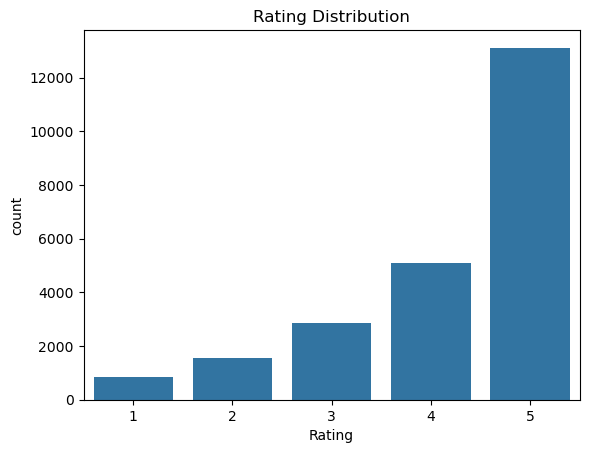

In [162]:
sns.countplot(x='Rating', data=df)
plt.title('Rating Distribution')
plt.show()

#### - Mostly high ratings -> positive bias

#### _Recommendation Distribution_

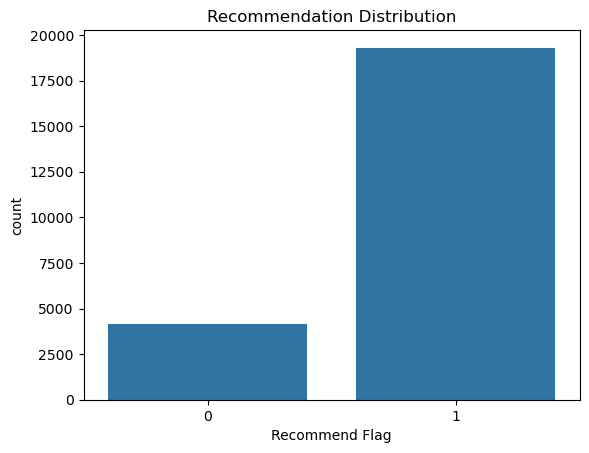

In [166]:
sns.countplot(x='Recommend Flag', data=df)
plt.title('Recommendation Distribution')
plt.show()

#### - Majority customers recommend products

#### _Age vs Rating_

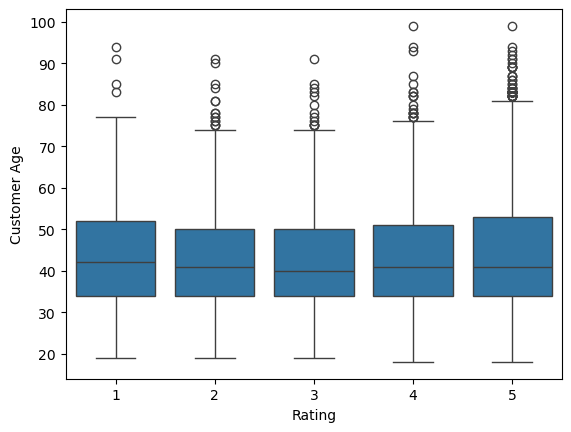

In [170]:
sns.boxplot(x='Rating',y='Customer Age', data=df)
plt.show()

#### - Age does not strongly affect rating

#### _Category Analysis_

In [174]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
Initmates         4.286285
General Petite    4.211084
General           4.176606
Name: Rating, dtype: float64

##### - All product categories have high average ratings above 4, indicating strong overall customer satisfaction.

#### _Channel Analysis_

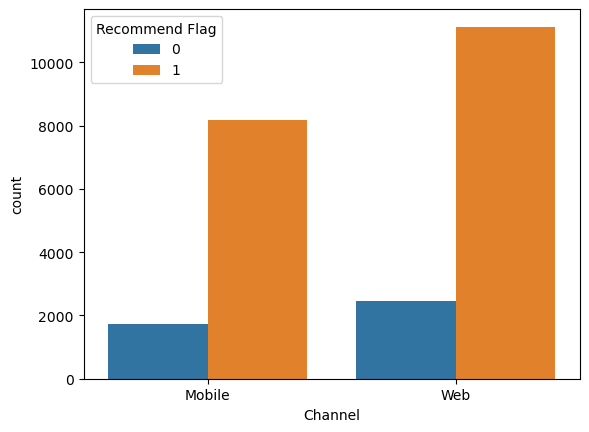

In [178]:
sns.countplot(x='Channel', hue= 'Recommend Flag', data=df)
plt.show()

##### - Web channel has higher user activity compared to mobile. In both channels, the majority of customers recommend the products, indicating overall satisfaction.

### Text Preprocessing

In [182]:
def cleaning_text(text):
    text=text.lower().strip()
    text=re.sub(r'http\S+|www\S+', 'link',text)
    text=re.sub(r'@\w+|#\w+', '', text)
    text=contractions.fix(text)
    text = re.sub(r'\.\.\.', ' ', text)
    text=re.sub(r'[^a-zA-Z\s]','',text)
    text=re.sub(r'\s+',' ',text)
    text=re.sub(r'\d+','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    return text
def sw_remove(text):
    text=[w for w in text.split() if w not in stop_word]
    return(' '.join(text))
def lemma(text):
    text=[lm.lemmatize(w,'v') for w in text.split()]
    return(' '.join(text))

In [184]:
def clean_text(text):
    text=cleaning_text(text)
    text=sw_remove(text)
    text=lemma(text) 
    return text

In [186]:
df.head(2)

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1


In [188]:
df['Clean_Text']=df['Review Text'].apply(lambda x: clean_text(x))
df.head()

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag,Clean_Text
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,absolutely wonderful silky sexy comfortable
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,love dress sooo pretty happen find store glad ...
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,high hop dress really want work initially orde...
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,love love love jumpsuit fun flirty fabulous ev...
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,shirt flatter due adjustable front tie perfect...


### Sentiment Approximation

In [191]:
df['Sentiment']=df['Rating'].apply(lambda x:'Positive' if x >= 4 else 'Negative')
df.head()

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag,Clean_Text,Sentiment
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,absolutely wonderful silky sexy comfortable,Positive
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,love dress sooo pretty happen find store glad ...,Positive
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,high hop dress really want work initially orde...,Negative
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,love love love jumpsuit fun flirty fabulous ev...,Positive
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,shirt flatter due adjustable front tie perfect...,Positive


### Word Cloud

#### _positive Reviews

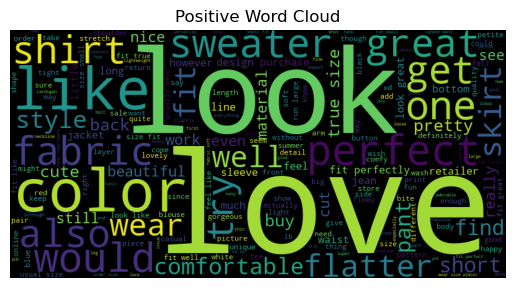

In [195]:
positive_text= ''.join(df[df['Sentiment']=='Positive']['Clean_Text'])

wordcloud= WordCloud(width=800, height=400, stopwords=['dress','top','think','make','go']).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive Word Cloud')
plt.show()

#### _Negative Reviews_

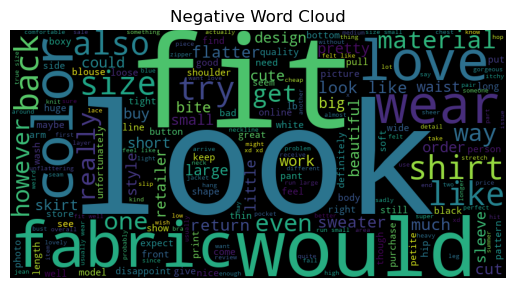

In [198]:
negative_text= ''.join(df[df['Sentiment']=='Negative']['Clean_Text'])

wordcloud= WordCloud(width=800, height=400, stopwords=['dress','top','think','make','go']).generate(negative_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Negative Word Cloud')
plt.show()

### Sentiment by Category

In [209]:
# Basic (Overall)
df['Sentiment'].value_counts(normalize=True)*100

Sentiment
Positive    77.513633
Negative    22.486367
Name: proportion, dtype: float64

In [211]:
df.head(2)

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag,Clean_Text,Sentiment
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,absolutely wonderful silky sexy comfortable,Positive
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,love dress sooo pretty happen find store glad ...,Positive


In [225]:
# Create Age_groups
df['Customer Age']=pd.cut(df['Customer Age'],bins=[0,20,30,40,50,60,100], labels=['0-20','20-30','30-40','40-50','50-60','60+'])

In [227]:
cols=['Category', 'Subcategory1','SubCategory2','Location','Customer Age']
for col in cols:
    print(f'\n------{col} vs Sentiment-----\n')
    print(pd.crosstab(df[col], df['Sentiment'], normalize='index')*100)


------Category vs Sentiment-----

Sentiment        Negative   Positive
Category                            
General         23.277978  76.722022
General Petite  21.773399  78.226601
Initmates       19.041278  80.958722

------Subcategory1 vs Sentiment-----

Sentiment      Negative   Positive
Subcategory1                      
Bottoms       19.505133  80.494867
Dresses       24.165216  75.834784
Intimate      19.077810  80.922190
Jackets       19.379845  80.620155
Tops          23.290027  76.709973
Trend         34.453782  65.546218

------SubCategory2 vs Sentiment-----

Sentiment        Negative    Positive
SubCategory2                         
Blouses         23.958670   76.041330
Casual bottoms   0.000000  100.000000
Chemises         0.000000  100.000000
Dresses         24.165216   75.834784
Fine gauge      20.363636   79.636364
Intimates       20.129870   79.870130
Jackets         19.176136   80.823864
Jeans           17.436792   82.563208
Knits           23.167458   76.832542
Laye

#### _The overall Sentiment analysis shows that approximately 77.5% of customers have positive sentiment while only 22.5% express negative sentiment. This indicates a high level of overall customer satisfaction._

### Predictive Model (Recommend Flag)

In [232]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [234]:
tfidf= TfidfVectorizer(max_features=5000)
x= tfidf.fit_transform(df['Clean_Text'])

y=df['Recommend Flag']

In [236]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y, test_size=0.20)
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((18777, 5000), (4695, 5000), (18777,), (4695,))

In [238]:
model=LogisticRegression()
model.fit(xtrain,ytrain)

LogisticRegression()

In [240]:
y_pred=model.predict(xtest)
y_pred[:5]

array([1, 1, 1, 1, 1], dtype=int64)

In [242]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.48      0.59       848
           1       0.89      0.97      0.93      3847

    accuracy                           0.88      4695
   macro avg       0.84      0.72      0.76      4695
weighted avg       0.87      0.88      0.87      4695



In [244]:
print(confusion_matrix(ytest, y_pred))

[[ 403  445]
 [ 112 3735]]


#### _-Model predicts recommendation using text_
#### _-High accuracy expected due to strong sentiment signal_

### Topic Modeling

In [251]:
vectorizer = CountVectorizer(max_df=0.9, min_df=10, stop_words='english')
X_count = vectorizer.fit_transform(df['Clean_Text'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_count)

LatentDirichletAllocation(n_components=5, random_state=42)

In [262]:
# Show topics
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i}")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 0
['fit', 'fabric', 'soft', 'great', 'wear', 'color', 'love', 'like', 'look', 'sweater']

Topic 1
['summer', 'flatter', 'look', 'fit', 'comfortable', 'perfect', 'great', 'love', 'wear', 'dress']

Topic 2
['small', 'store', 'try', 'wear', 'buy', 'order', 'love', 'fit', 'color', 'size']

Topic 3
['long', 'wear', 'short', 'little', 'size', 'love', 'shirt', 'like', 'fit', 'look']

Topic 4
['love', 'large', 'fabric', 'order', 'look', 'like', 'small', 'fit', 'size', 'dress']
